# EDA - Good Game Database Analysis

This notebook performs a first pass of exploratory data analysis on the GoodGame bronze-stage data.


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for inline plotting in Jupyter
%matplotlib inline

# Set seaborn style for better aesthetics
sns.set_style("whitegrid")


In [2]:
# Estabblish connection to Snowflake
conn = snowflake.connector.connect(
    user=os.getenv('SF_USER'),
    password=os.getenv('SF_PASSWORD'),
    account=os.getenv('SF_ACCOUNT'),
    database=os.getenv('SF_DATABASE'),
    schema=os.getenv('SF_SCHEMA'),
    warehouse=os.getenv('SF_WAREHOUSE')
)

# Fetch data into pandas DataFrames
with conn.cursor() as cur:
    cur.execute("USE DATABASE good_game_db")
    cur.execute("USE SCHEMA public")

    # Query all 4 tables
    tables = ["players", "game_sessions", "checkpoint_events", "sentiment_responses"]
    dataframes = {}

    for table_name in tables:
        query = f"SELECT * FROM {table_name}"
        cur.execute(query)
        dataframes[table_name] = cur.fetch_pandas_all()

# Close the connection
conn.close()

In [3]:
for table_name, df in dataframes.items():
    print(f"TABLE: {table_name.upper()}")
    display(df)

TABLE: PLAYERS


,ID,UUID,DISPLAY_NAME,CREATED_AT
0,1,af0aacb9-8075-44d5-b1c0-47463f5dcb67,gael,2026-04-19 17:35:11.170845-07:00
1,2,a237790d-2483-415d-a7db-05ba2bb5b533,Toutl,2026-04-20 17:35:16.681645-07:00
2,3,18e547bf-541e-439f-84c7-638e8b423a28,Dick,2026-04-21 12:22:50.174766-07:00
3,4,976b5698-1f34-4c81-9ecf-f48af689ef6c,alsjn,2026-04-21 19:19:32.897302-07:00
4,5,9589786d-0465-48c6-9c1a-698861d35a13,The Messiah,2026-04-21 19:26:53.605376-07:00
...,...,...,...,...
63,64,6661f97a-a8ea-4132-9bc8-ca0ff1cc434f,MARTIN,2026-05-05 08:20:23.846654-07:00
64,65,c7c940e3-4f7a-4ccf-ae4f-fdf267cb8592,Estefy,2026-05-05 08:20:34.574639-07:00
65,66,957d0d49-880f-44cc-88bb-cd7f62459b61,vale,2026-05-05 08:20:43.941646-07:00
66,67,485d5c1d-5ad1-49c3-a30b-3df5c03ff2be,Mariana,2026-05-05 08:20:44.247766-07:00


TABLE: GAME_SESSIONS


,ID,PLAYER_ID,LEVEL,DEATHS,TIME_SECONDS,SCORE,TOTAL_JUMPS,MAX_X_REACHED,SCORE_RESETS,COMPLETED,CREATED_AT
0,1,1,1,0,19.13,1462,12,3808.33,0,True,2026-04-19 17:35:33.864328-07:00
1,2,1,2,3,40.79,1345,28,4807.00,0,True,2026-04-19 17:36:36.927876-07:00
2,3,1,3,6,48.37,1254,33,4316.33,0,True,2026-04-19 17:37:40.081025-07:00
3,4,2,1,1,24.95,1427,13,3808.33,0,True,2026-04-20 17:36:21.068410-07:00
4,5,2,2,8,70.53,1160,39,4807.00,0,True,2026-04-20 17:38:21.394380-07:00
...,...,...,...,...,...,...,...,...,...,...,...
203,204,67,3,36,191.02,218,94,4309.33,0,True,2026-05-05 08:32:23.834537-07:00
204,205,56,2,65,539.71,0,356,4809.33,10,True,2026-05-05 08:32:52.393972-07:00
205,206,61,3,55,246.60,111,162,4309.33,2,True,2026-05-05 08:33:03.429938-07:00
206,207,64,3,16,79.54,942,48,4313.00,0,True,2026-05-05 08:33:40.339314-07:00


TABLE: CHECKPOINT_EVENTS


,ID,SESSION_ID,CHECKPOINT_INDEX,REACHED_AT_SECONDS,DEATHS_SO_FAR
0,1,1,0,5.48,0
1,2,1,1,12.14,0
2,3,2,0,9.26,1
3,4,2,1,18.48,1
4,5,2,2,35.87,3
...,...,...,...,...,...
539,540,207,1,57.63,12
540,541,208,0,31.83,4
541,542,208,1,259.12,57
542,543,208,2,335.69,65


TABLE: SENTIMENT_RESPONSES


,ID,SESSION_ID,PLAYER_ID,EMOJI_MOOD,COLOR_MOOD,WORD,SKIPPED,CREATED_AT
0,1,1,1,4,green,easy,False,2026-04-19 17:35:47.576377-07:00
1,2,3,1,4,blue,bien,False,2026-04-19 17:37:49.821264-07:00
2,3,4,2,4,blue,nice,False,2026-04-20 17:36:57.583174-07:00
3,4,6,2,3,orange,concerned,False,2026-04-20 17:45:05.045288-07:00
4,5,8,2,3,green,better,False,2026-04-20 17:49:37.246344-07:00
...,...,...,...,...,...,...,...,...
106,107,201,60,3,blue,mo,False,2026-05-05 08:31:25.774101-07:00
107,108,200,55,3,yellow,dificil,False,2026-05-05 08:31:58.586212-07:00
108,109,204,67,3,blue,fun,False,2026-05-05 08:32:47.920147-07:00
109,110,206,61,1,blue,676767676767676767676767676767,False,2026-05-05 08:33:44.806471-07:00


In [4]:
# Make copies of the original DFs
dfs = {}
for table_name, df in dataframes.items():
    dfs[table_name] = df.copy()
    dfs[table_name].columns = dfs[table_name].columns.str.lower()

## EDA

### `players` table

In [5]:
players = dfs["players"].drop(columns=["uuid"])
players

,id,display_name,created_at
0,1,gael,2026-04-19 17:35:11.170845-07:00
1,2,Toutl,2026-04-20 17:35:16.681645-07:00
2,3,Dick,2026-04-21 12:22:50.174766-07:00
3,4,alsjn,2026-04-21 19:19:32.897302-07:00
4,5,The Messiah,2026-04-21 19:26:53.605376-07:00
...,...,...,...
63,64,MARTIN,2026-05-05 08:20:23.846654-07:00
64,65,Estefy,2026-05-05 08:20:34.574639-07:00
65,66,vale,2026-05-05 08:20:43.941646-07:00
66,67,Mariana,2026-05-05 08:20:44.247766-07:00


In [6]:
# Repeated player names
players['display_name'].value_counts().loc[lambda x: x > 1]

display_name
Santiago    2
Name: count, dtype: int64

### `game_sessions` table

In [7]:
game_sessions = dfs["game_sessions"].drop(columns=["completed"])
game_sessions

,id,player_id,level,deaths,time_seconds,score,total_jumps,max_x_reached,score_resets,created_at
0,1,1,1,0,19.13,1462,12,3808.33,0,2026-04-19 17:35:33.864328-07:00
1,2,1,2,3,40.79,1345,28,4807.00,0,2026-04-19 17:36:36.927876-07:00
2,3,1,3,6,48.37,1254,33,4316.33,0,2026-04-19 17:37:40.081025-07:00
3,4,2,1,1,24.95,1427,13,3808.33,0,2026-04-20 17:36:21.068410-07:00
4,5,2,2,8,70.53,1160,39,4807.00,0,2026-04-20 17:38:21.394380-07:00
...,...,...,...,...,...,...,...,...,...,...
203,204,67,3,36,191.02,218,94,4309.33,0,2026-05-05 08:32:23.834537-07:00
204,205,56,2,65,539.71,0,356,4809.33,10,2026-05-05 08:32:52.393972-07:00
205,206,61,3,55,246.60,111,162,4309.33,2,2026-05-05 08:33:03.429938-07:00
206,207,64,3,16,79.54,942,48,4313.00,0,2026-05-05 08:33:40.339314-07:00


In [8]:
dfs["game_sessions"].describe().T

,count,mean,std,min,25%,50%,75%,max
id,208.0,104.500000,60.188592,1.00,52.750,104.500,156.2500,208.00
player_id,208.0,26.778846,20.134551,1.00,11.000,20.500,43.0000,68.00
level,208.0,2.754808,1.857866,1.00,1.000,2.000,4.0000,7.00
deaths,208.0,21.293269,21.103050,0.00,7.000,15.000,27.2500,154.00
time_seconds,208.0,141.991298,131.860375,18.38,60.215,103.940,168.6725,1010.93
score,208.0,811.043269,455.585479,0.00,413.250,901.500,1193.7500,1464.00
total_jumps,208.0,75.673077,66.647453,12.00,36.000,62.000,92.2500,623.00
max_x_reached,208.0,4581.310673,657.543552,3799.67,3809.670,4806.335,5008.6700,5810.00
score_resets,208.0,1.567308,8.437625,0.00,0.000,0.000,0.0000,98.00


In [9]:
# Ammount of players that passed each level
game_sessions.drop_duplicates(subset=["player_id", "level"])['level'].value_counts()

level
1    61
2    46
3    29
4    18
5     9
6     8
7     6
Name: count, dtype: int64

In [10]:
# Average deaths per level
game_sessions.groupby('level')['deaths'].mean().round(2)

level
1    11.67
2    26.81
3    20.29
4    11.25
5    49.21
6    24.55
7    36.57
Name: deaths, dtype: float64

In [11]:
# Average time to comlete the levels
game_sessions.groupby('level')['time_seconds'].mean().round(2)

level
1     92.07
2    155.26
3    126.47
4     78.32
5    343.26
6    191.94
7    230.93
Name: time_seconds, dtype: float64

In [12]:
# Average ammount of jumps per levels
game_sessions.groupby('level')['total_jumps'].mean().round(2)

level
1     45.46
2     82.98
3     71.77
4     49.50
5    181.36
6     86.91
7    133.21
Name: total_jumps, dtype: float64

### `checkpoint_events` table

In [13]:
checkpoint_events = dfs['checkpoint_events'].drop(columns=["id"])
checkpoint_events

,session_id,checkpoint_index,reached_at_seconds,deaths_so_far
0,1,0,5.48,0
1,1,1,12.14,0
2,2,0,9.26,1
3,2,1,18.48,1
4,2,2,35.87,3
...,...,...,...,...
539,207,1,57.63,12
540,208,0,31.83,4
541,208,1,259.12,57
542,208,2,335.69,65


In [14]:
dfs["checkpoint_events"].describe().T

,count,mean,std,min,25%,50%,75%,max
id,544.0,272.500000,157.183545,1.00,136.7500,272.50,408.2500,544.00
session_id,544.0,100.665441,60.114242,1.00,47.0000,100.50,152.0000,208.00
checkpoint_index,544.0,0.917279,0.882902,0.00,0.0000,1.00,1.0000,3.00
reached_at_seconds,544.0,90.763952,121.452734,5.39,21.9625,48.82,111.7475,984.63
deaths_so_far,544.0,13.702206,19.407701,0.00,2.0000,6.00,17.0000,147.00


### `sentiment_responses` table

In [15]:
sentiment_responses = dfs["sentiment_responses"].drop(columns=["skipped", 'id', 'player_id'])
sentiment_responses

,session_id,emoji_mood,color_mood,word,created_at
0,1,4,green,easy,2026-04-19 17:35:47.576377-07:00
1,3,4,blue,bien,2026-04-19 17:37:49.821264-07:00
2,4,4,blue,nice,2026-04-20 17:36:57.583174-07:00
3,6,3,orange,concerned,2026-04-20 17:45:05.045288-07:00
4,8,3,green,better,2026-04-20 17:49:37.246344-07:00
...,...,...,...,...,...
106,201,3,blue,mo,2026-05-05 08:31:25.774101-07:00
107,200,3,yellow,dificil,2026-05-05 08:31:58.586212-07:00
108,204,3,blue,fun,2026-05-05 08:32:47.920147-07:00
109,206,1,blue,676767676767676767676767676767,2026-05-05 08:33:44.806471-07:00


In [16]:
sentiment_responses["word"].dropna().value_counts()

word
fun                               5
easy                              4
bien                              3
great                             3
happy                             2
chido                             2
epic                              2
67                                2
good                              2
concerned                         1
dogshit                           1
better                            1
hola                              1
nota de suicidio - Porta          1
bullshit                          1
sex                               1
goofy                             1
ffffff                            1
rage bait                         1
ugly shit                         1
trahs                             1
fucking easy                      1
whe this shit goes harder?        1
mmmh                              1
cant stop the pain                1
angry                             1
no aguanto mas                    1
nice                   

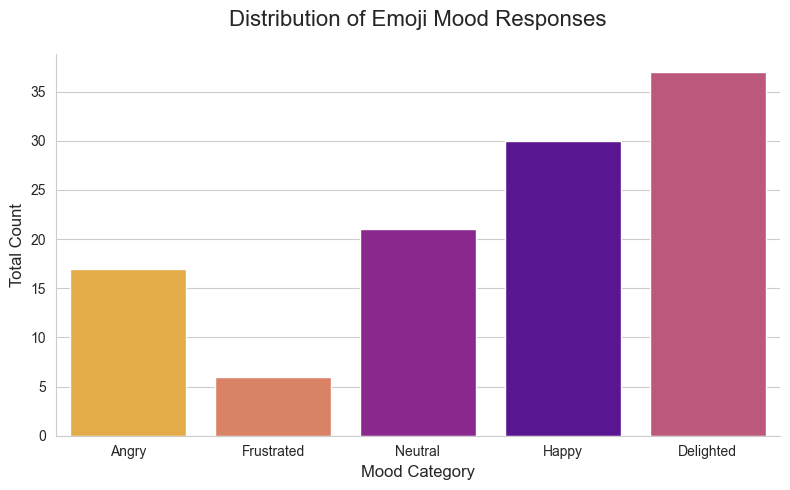

In [37]:
# Plot 'emoji_mood' distribution
plt.figure(figsize=(8,5))
sns.countplot(
    data=sentiment_responses.replace({'emoji_mood': {1: "Angry", 2: "Frustrated", 3: "Neutral", 4: "Happy", 5: "Delighted"}}),
    x='emoji_mood',
    order=["Angry", "Frustrated", "Neutral", "Happy", "Delighted"],
    palette='plasma',
    hue='emoji_mood',
    legend=False
)

plt.title('Distribution of Emoji Mood Responses', fontsize=16, pad=20)
plt.xlabel('Mood Category', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

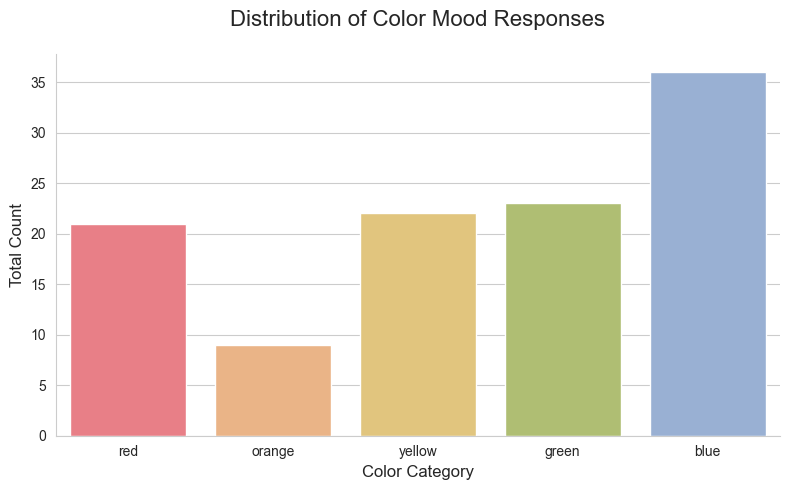

In [24]:
# Plot 'color_mood' distribution
color_map = {
    "red": "#F96E78",
    "orange": "#FAB277",
    "yellow": "#F2CC6D",
    "green": "#B6CB66",
    "blue": "#8FAEDD",
}

plt.figure(figsize=(8,5))
sns.countplot(
    data=sentiment_responses, 
    x='color_mood', 
    order=['red', 'orange', 'yellow', 'green', 'blue'],
    palette=color_map,
    hue='color_mood', 
    legend=False
)

plt.title('Distribution of Color Mood Responses', fontsize=16, pad=20)
plt.xlabel('Color Category', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()